<a href="https://colab.research.google.com/github/ekuelkpodar/Complex-Systems-Google-Colab-Experiment/blob/main/Geopolitical_Conflict_Escalation_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Develop a comprehensive geopolitical conflict and escalation simulator within Google Colab. This project involves modeling nation-state agents as nodes in a dynamic network, incorporating game-theoretic decision-making, economic interdependencies, and alliance dynamics. The simulator will allow users to model complex interactions such as trade wars, proxy conflicts, and military escalations while providing visualization tools for network analysis and scenario forecasting.

## Define Mathematical Framework and Data Schema

### Subtask:
Establish the foundational data structures and mathematical representations for the simulation, specifically the nation-state properties and the network representation of international relations.


**Reasoning**:
I will begin by importing the necessary libraries and defining the core data structures for the nation-state agents and the geopolitical network graph.



In [1]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class NationState:
    def __init__(self, name, gdp, military_strength, stability):
        self.name = name
        self.gdp = gdp
        self.military_strength = military_strength
        self.stability = stability
        self.resources = {'wealth': gdp, 'arms': military_strength}

    def __repr__(self):
        return f"Nation({self.name})"

# Initialize the geopolitical network
G = nx.Graph()

# Example nodes (Major Powers)
major_powers = [
    NationState("State_A", 20000, 1000, 0.9),
    NationState("State_B", 18000, 950, 0.85),
    NationState("State_C", 12000, 400, 0.95)
]

for state in major_powers:
    G.add_node(state.name, data=state)

print(f"Initialized network with {len(G.nodes)} states.")

Initialized network with 3 states.


**Reasoning**:
I will add edges to the graph to represent trade and alliance relationships between the states, completing the mathematical representation of the network.



In [2]:
# Add edges representing relationships: (Node1, Node2, trade_volume, alliance_type)
# alliance_type: 0 = Neutral, 1 = Defense Pact, -1 = Rivalry
relationships = [
    ("State_A", "State_B", 500, 1),
    ("State_B", "State_C", 300, 0),
    ("State_A", "State_C", 150, -1)
]

for u, v, trade, alliance in relationships:
    G.add_edge(u, v, trade_volume=trade, alliance=alliance)

print("Network Edges added:")
for u, v, d in G.edges(data=True):
    print(f"{u} <-> {v}: Trade={d['trade_volume']}, Alliance={d['alliance']}")

Network Edges added:
State_A <-> State_B: Trade=500, Alliance=1
State_A <-> State_C: Trade=150, Alliance=-1
State_B <-> State_C: Trade=300, Alliance=0


## Initialize Agent-Based Model (ABM)

### Subtask:
Enhance the nation-state agents with internal logic and intelligence attributes to facilitate decision-making in the simulation.


**Reasoning**:
I will update the `NationState` class definition to include an 'intelligence' attribute and a method to calculate the 'power_index', which are essential for the agent-based decision logic.



In [3]:
class NationState:
    def __init__(self, name, gdp, military_strength, stability, intelligence=0.5):
        self.name = name
        self.gdp = gdp
        self.military_strength = military_strength
        self.stability = stability
        self.intelligence = intelligence  # Scale 0-1 representing info access
        self.resources = {'wealth': gdp, 'arms': military_strength}
        self.history = [] # To track state changes

    def get_power_index(self):
        # Simple weighted power index
        return (self.gdp * 0.4) + (self.military_strength * 0.6) * self.stability

    def __repr__(self):
        return f"Nation({self.name}, Power={self.get_power_index():.1f})"

# Re-initialize the states in the network with the new class definition
major_powers_updated = [
    NationState("State_A", 20000, 1000, 0.9, 0.8),
    NationState("State_B", 18000, 950, 0.85, 0.7),
    NationState("State_C", 12000, 400, 0.95, 0.6)
]

for state in major_powers_updated:
    G.nodes[state.name]['data'] = state

print("ABM Agents Initialized:")
for node in G.nodes(data=True):
    state_obj = node[1]['data']
    print(f"{state_obj.name}: Power Index = {state_obj.get_power_index():.2f}, Intel = {state_obj.intelligence}")

ABM Agents Initialized:
State_A: Power Index = 8540.00, Intel = 0.8
State_B: Power Index = 7684.50, Intel = 0.7
State_C: Power Index = 5028.00, Intel = 0.6


## Model Economic and Trade Systems

### Subtask:
Create the system dynamics for trade relationships and economic dependencies, including logic for trade wars and sanctions.


**Reasoning**:
I will update the `NationState` class to include methods for handling trade impacts and sanctions, and then demonstrate a simple trade war scenario between two rival states.



In [4]:
import random

def apply_sanctions(graph, state_a_name, state_b_name, intensity=0.2):
    """Applies sanctions between two states, reducing trade and wealth."""
    if graph.has_edge(state_a_name, state_b_name):
        edge_data = graph[state_a_name][state_b_name]
        original_trade = edge_data['trade_volume']
        reduction = original_trade * intensity
        edge_data['trade_volume'] -= reduction

        # Update state resources based on trade loss
        for name in [state_a_name, state_b_name]:
            state = graph.nodes[name]['data']
            loss = reduction * 0.5 # Simplified economic impact factor
            state.resources['wealth'] -= loss
            state.stability -= (intensity * 0.05) # Sanctions reduce stability
            state.history.append(f"Sanction impact: wealth -{loss:.1f}, stability -{intensity*0.05:.2f}")

        return f"Sanctions applied between {state_a_name} and {state_b_name}. Trade reduced by {reduction}."
    return "No trade relationship found."

def simulate_trade_step(graph):
    """Simulates a single time step of trade-based wealth generation."""
    for u, v, d in graph.edges(data=True):
        trade_vol = d['trade_volume']
        # Trade generates wealth for both parties proportional to volume
        for node_name in [u, v]:
            state = graph.nodes[node_name]['data']
            gain = trade_vol * 0.05
            state.resources['wealth'] += gain
    return "Wealth generated from trade."

# Scenario: State_A imposes sanctions on State_C due to Rivalry
print(f"Initial Wealth State_A: {G.nodes['State_A']['data'].resources['wealth']}")
print(apply_sanctions(G, 'State_A', 'State_C', intensity=0.5))
print(f"Post-Sanction Wealth State_A: {G.nodes['State_A']['data'].resources['wealth']:.2f}")
print(f"Post-Sanction Stability State_A: {G.nodes['State_A']['data'].stability:.2f}")

# Run a trade cycle
simulate_trade_step(G)
print("Trade cycle complete.")

Initial Wealth State_A: 20000
Sanctions applied between State_A and State_C. Trade reduced by 75.0.
Post-Sanction Wealth State_A: 19962.50
Post-Sanction Stability State_A: 0.88
Trade cycle complete.


## Implement Conflict and Alliance Logic

### Subtask:
Develop the simulation engine for proxy wars and military conflicts, incorporating dynamic alliance formation and power transitions.


**Reasoning**:
I will update the `NationState` class and define functions to handle conflict resolution and utility-based alliance formation.



In [5]:
import random

def calculate_utility(state):
    # Utility is a balance of wealth and security (stability * military)
    return (state.resources['wealth'] * 0.3) + (state.get_power_index() * 0.7)

def resolve_conflict(graph, state_a_name, state_b_name):
    state_a = graph.nodes[state_a_name]['data']
    state_b = graph.nodes[state_b_name]['data']

    power_a = state_a.get_power_index()
    power_b = state_b.get_power_index()

    # Probability of A winning
    win_prob = power_a / (power_a + power_b)
    outcome = "Win" if random.random() < win_prob else "Loss"

    # Impact of conflict
    if outcome == "Win":
        state_a.resources['wealth'] += 100
        state_b.resources['wealth'] -= 200
        state_b.stability -= 0.1
        return f"{state_a_name} defeated {state_b_name}."
    else:
        state_b.resources['wealth'] += 100
        state_a.resources['wealth'] -= 200
        state_a.stability -= 0.1
        return f"{state_b_name} successfully defended against {state_a_name}."

def check_alliance_triggers(graph, attacker, target):
    # Simple logic: If target has a defense pact (alliance=1), allies join the defense
    allies = []
    for neighbor in graph.neighbors(target):
        if graph[target][neighbor].get('alliance') == 1:
            allies.append(neighbor)
    return allies

# Scenario: State_C (the underdog) is attacked by State_A
print(f"Initial Power State_C: {G.nodes['State_C']['data'].get_power_index():.2f}")
defense_allies = check_alliance_triggers(G, 'State_A', 'State_C')
print(f"Allies joining State_C in defense: {defense_allies}")

# Execute conflict
result = resolve_conflict(G, 'State_A', 'State_C')
print(f"Conflict Result: {result}")
print(f"Post-Conflict Stability State_C: {G.nodes['State_C']['data'].stability:.2f}")

Initial Power State_C: 5022.00
Allies joining State_C in defense: []
Conflict Result: State_C successfully defended against State_A.
Post-Conflict Stability State_C: 0.92


## Develop Visualization and Scenario Analysis

### Subtask:
Create a visualization suite to represent the geopolitical network and plot the evolution of state metrics over a multi-step simulation scenario.


**Reasoning**:
I will start by creating a function to visualize the current state of the geopolitical network, using edge colors to distinguish between defense pacts, neutral relations, and rivalries.



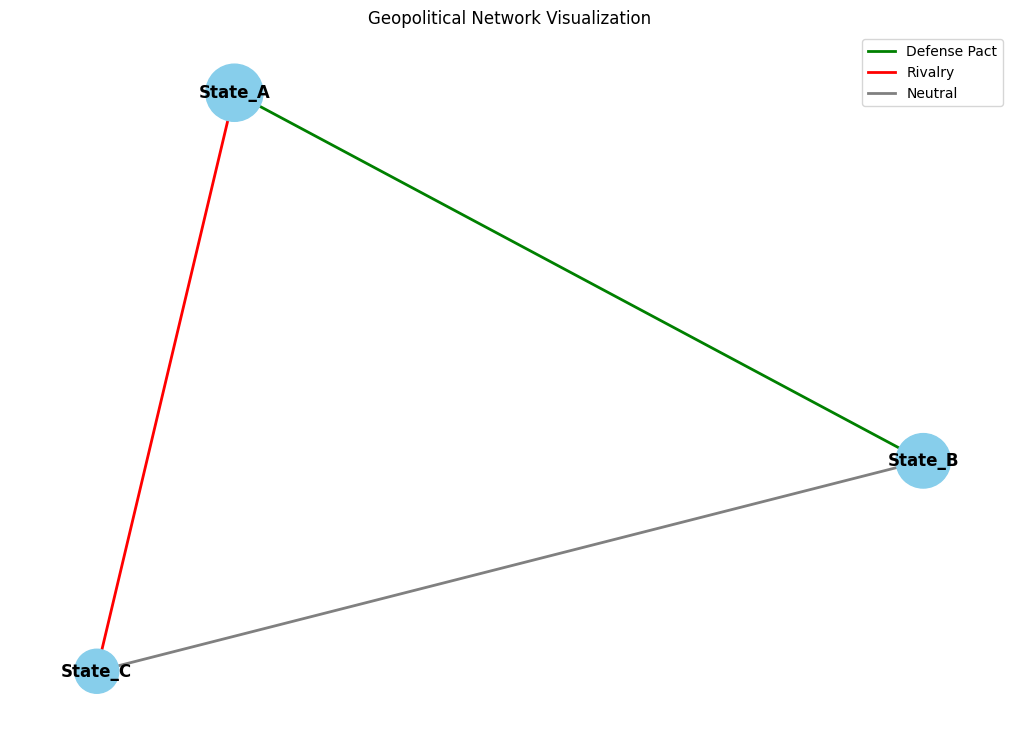

In [6]:
def visualize_geopolitical_network(graph):
    pos = nx.spring_layout(graph, seed=42)

    # Node sizes based on power index
    node_sizes = [graph.nodes[node]['data'].get_power_index() * 0.2 for node in graph.nodes()]

    # Edge colors based on alliance type
    edge_colors = []
    for u, v, d in graph.edges(data=True):
        if d['alliance'] == 1: edge_colors.append('green') # Defense Pact
        elif d['alliance'] == -1: edge_colors.append('red') # Rivalry
        else: edge_colors.append('gray') # Neutral

    plt.figure(figsize=(10, 7))
    nx.draw(graph, pos, with_labels=True, node_size=node_sizes, node_color='skyblue',
            edge_color=edge_colors, width=2, font_weight='bold')

    # Custom legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='green', lw=2, label='Defense Pact'),
        Line2D([0], [0], color='red', lw=2, label='Rivalry'),
        Line2D([0], [0], color='gray', lw=2, label='Neutral')
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    plt.title("Geopolitical Network Visualization")
    plt.show()

visualize_geopolitical_network(G)

**Reasoning**:
I will create a simulation loop that runs for multiple steps, recording the wealth and power index of each state, and then visualize these trends using line plots.



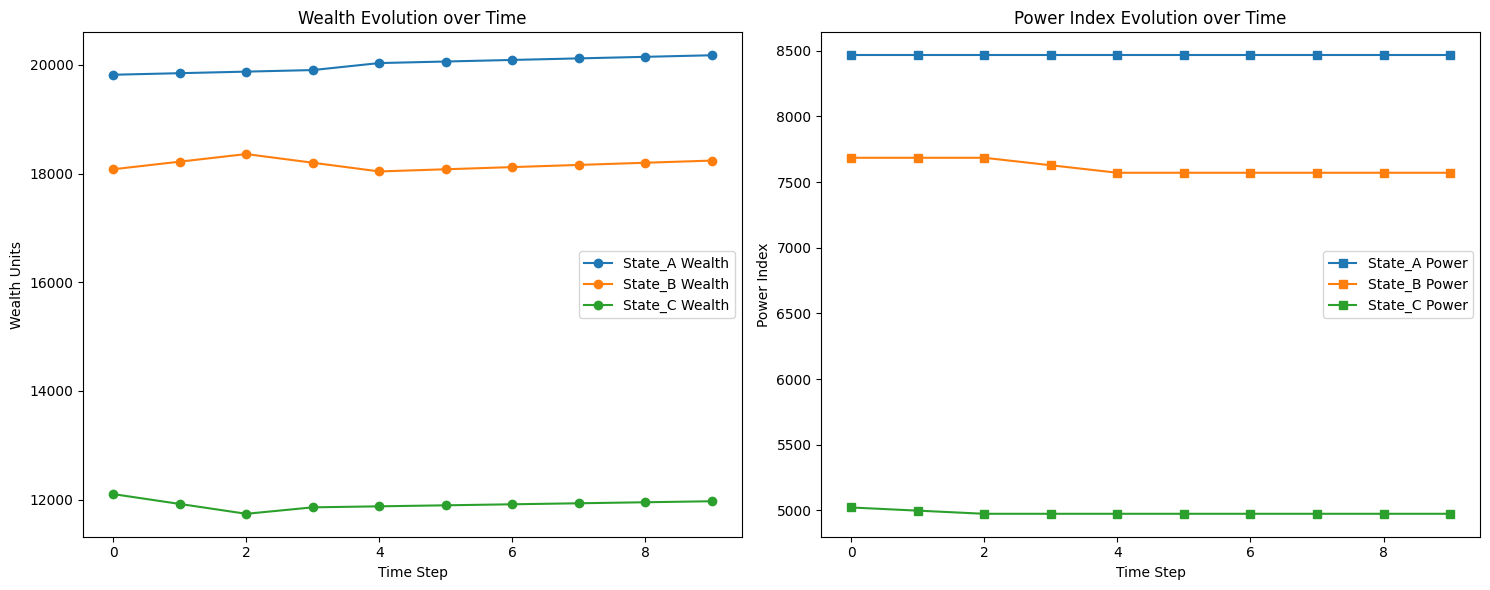

In [7]:
def run_scenario(graph, steps=10):
    history = {node: {'wealth': [], 'power': []} for node in graph.nodes()}

    for i in range(steps):
        # 1. Economic Step
        simulate_trade_step(graph)

        # 2. Random Event: Small chance of a friction leading to a minor conflict
        if random.random() < 0.3:
            nodes = list(graph.nodes())
            a, b = random.sample(nodes, 2)
            resolve_conflict(graph, a, b)

        # Record stats
        for node in graph.nodes():
            state = graph.nodes[node]['data']
            history[node]['wealth'].append(state.resources['wealth'])
            history[node]['power'].append(state.get_power_index())

    return history

# Run simulation
sim_history = run_scenario(G, steps=10)

# Plotting results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

for node, data in sim_history.items():
    ax1.plot(data['wealth'], label=f"{node} Wealth", marker='o')
    ax2.plot(data['power'], label=f"{node} Power", marker='s')

ax1.set_title("Wealth Evolution over Time")
ax1.set_xlabel("Time Step")
ax1.set_ylabel("Wealth Units")
ax1.legend()

ax2.set_title("Power Index Evolution over Time")
ax2.set_xlabel("Time Step")
ax2.set_ylabel("Power Index")
ax2.legend()

plt.tight_layout()
plt.show()